In [1]:
import pandas as pd

In [2]:
#Import raw GDP data
#Data from https://doi.org/10.2908/NAMA_10_GDP
df_gdp = pd.read_csv('gdp_short.tsv', delimiter='\t')

#Recover relevant index, namely region, from first column
indices = list(df_gdp[r'freq,unit,na_item,geo\TIME_PERIOD'])
regions = []
for i in indices:
    regions.append(i.split(',')[-1])
    
df_gdp['Region'] = regions
df_gdp.set_index('Region', inplace=True)
df_gdp.drop(r'freq,unit,na_item,geo\TIME_PERIOD', axis=1, inplace=True)
df_gdp.head(10)

,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
AL,:,:,:,:,:,:,:,:,:,:,...,10835.1,11770.8,13016.9,13917.9,13379.5,15243.1,18068.1,21730.5,25000.7 p,:
AT,:,:,:,:,:,:,:,:,:,:,...,355665.6,367294.9,383234.3,395706.8,380317.9,406231.5,449382.2,477837.3,494087.6,514328.1
BA,:,:,:,:,:,:,:,:,:,:,...,15474.3,16260.5,17354.2,18296.5,17755.9,20014.7,23324.1,25523.8,27483.1,28913.9
BE,:,:,:,:,:,:,:,:,:,:,...,428467.1,443407.2,459491.8,479444.9,463750.9,506047.2,561678.2,601866.5,619914.3 p,642015.3 p
BG,:,:,:,:,:,:,:,:,:,:,...,48751.4,52501.0,55999.7,61194.4,61855.6,71343.9,86078.2,94525.1,104767.2,116018.3 p
CH,:,:,:,:,:,:,:,:,:,:,...,631447.6,625926.6,627171.6,657857.6,663105.6,710646.0,815869.1,858396.6,896448.7,925874.8
CY,:,:,:,:,:,:,:,:,:,:,...,19013.8,20312.4,21807.8,23400.9,22373.6,25679.9,29645.4,32439.2,34770.2 p,36483.5 p
CZ,:,:,:,:,:,:,:,:,:,:,...,179145.9,196738.7,213505.4,229406.7,220310.6,246012.3,286976.8,319099.1,320786.5,346583.4
DE,:,:,:,:,:,:,:,:,:,:,...,3195210.0,3333110.0,3434030.0,3537280.0,3450720.0,3682340.0,3989390.0 p,4219310.0 p,4328970.0 p,4469810.0 p


In [3]:
#Import first life expectancy dataset (95-03)
#Data from https://doi.org/10.2908/HLTH_HLYE_H
df_le_1 = pd.read_csv('life_expect_1.tsv', delimiter='\t')

#Recover from index region and feature (combination of sex and LE from 0, 50 or 65)
indices = list(df_le_1[r'freq,indic_he,geo\TIME_PERIOD'])
regions = []
categories = []
for i in indices:
    l = i.split(',')
    regions.append(l[-1])
    categories.append(l[1])

df_le_1['Region'] = regions
df_le_1['Category'] = categories
df_le_1.set_index(['Category','Region'], inplace=True)
df_le_1.drop(r'freq,indic_he,geo\TIME_PERIOD', axis=1, inplace=True)
df_le_1.head(10)

1995   1996   1997   1998   1999   2000   2001   2002   2003 
Category Region                                                               
F_0_LE   AT      80.1   80.2   80.7     81     81   81.2   81.7   81.7   81.5 
         BE      80.4   80.7   80.7   80.7     81     81   81.2   81.2   81.1 
         BG      74.9   74.5   73.8   74.6     75     75   75.4   75.5   75.9 
         CY      79.6     80     80   79.8   79.9   80.1   81.4     81   81.2 
         CZ      76.8   77.5   77.6   78.2   78.3   78.5   78.6   78.7   78.6 
         DE      79.9   80.1   80.5   80.8     81   81.2   81.4   81.3   81.3 
         DK      77.9   78.3   78.6     79     79   79.2   79.3   79.4   79.8 
         EA15    80.9     81   81.4   81.5   81.7   81.9   82.2   82.2     82 
         EE      74.3   75.6   75.9   75.4     76   76.2   76.4     77   77.1 
         EL      80.1   80.2   80.4   80.3   80.5   80.6     81   81.1   81.2

In [4]:
#Import second life expectancy dataset (04-24)
#Data from https://doi.org/10.2908/HLTH_HLYE
df_le_2 = pd.read_csv('life_expect_2.tsv', delimiter='\t')

#Recover from index region and feature (combination of sex and LE from 0, 50 or 65)
indices = list(df_le_2[r'freq,unit,sex,hlth_hle,geo\TIME_PERIOD'])
regions = []
categories = []
for i in indices:
    l = i.split(',')
    regions.append(l[-1])
    categories.append('_'.join(l[2:4]))

df_le_2['Region'] = regions
df_le_2['Category'] = categories
df_le_2.set_index(['Category','Region'], inplace=True)
df_le_2.drop(r'freq,unit,sex,hlth_hle,geo\TIME_PERIOD', axis=1, inplace=True)
df_le_2.head(10)

2004   2005   2006   2007   2008   2009   2010   2011   \
Category Region                                                           
F_LE_Y0  AT       82.1   82.2   82.8   83.1   83.3   83.2  83.5    83.8   
         BE       81.9   81.9   82.3   82.6   82.6   82.8  83.0    83.3   
         BG       76.2   76.2   76.3   76.6   77.0   77.4  77.4    77.8   
         CH       83.8   84.0   84.2   84.4   84.6   84.6  84.9    85.0   
         CY       81.8   80.8   82.0   82.1   82.9   83.5  83.9    83.1   
         CZ       79.1   79.2   79.9   80.2   80.5   80.5  80.9    81.1   
         DE       81.9   82.0   82.4   82.7   82.7   82.8  83.0    83.1   
         DK       80.2   80.5   80.7   80.6   81.0   81.1  81.4    81.9   
         EE       78.0   78.2   78.6   78.9   79.5   80.3  80.8    81.3   
         EL       82.2   82.5   82.7   82.5   83.0   83.3  83.3    83.6   

                 2012   2013   ...  2015   2016   2017   2018   2019   2020   \
Category Region                ...                                             
F_LE_Y0  AT      83.6   83.8   ...   83.7   84.1   84.0   84.1  84.2   83.6    
         BE      83.1   83.2   ...   83.4   84.0   83.9   83.9  84.3   83.0    
         BG      77.9   78.6   ...   78.2   78.5   78.4   78.6  78.8   77.5    
         CH      84.9   85.0   ...   85.1   85.6   85.6   85.7  85.8   85.1    
         CY      83.4   85.0   ...   83.7   84.9   84.2   84.8  84.4   84.4    
         CZ      81.2   81.3   ...   81.6   82.1   82.0   82.0  82.2   81.3    
         DE      83.1   83.0   ...   83.1   83.5   83.4   83.3  83.7   83.5    
         DK      82.1   82.4   ...   82.7   82.8   83.1   82.9  83.5   83.6    
         EE      81.5   81.7   ...   82.2   82.2   82.6   82.7  83.0   83.0    
         EL      83.4   84.0   ...   83.7   84.0   83.9   84.4  84.2   83.9    

                 2021   2022    2023   2024   
Category Region                               
F_LE_Y0  AT      83.7   83.6    84.2   84.3   
         BE      84.3   83.9    84.5   84.4   
         BG      75.1   77.9    79.7   79.5   
         CH      85.8   85.5    86.0   85.9   
         CY      83.4   83.4    85.3   85.6   
         CZ      80.5   81.9    82.9   83.0   
         DE      83.3   83.0   83.5 b  83.5   
         DK      83.3   83.2    83.7   83.9   
         EE      81.4   82.3    83.3   83.4   
         EL      82.9   83.4    84.4   84.4   

[10 rows x 21 columns]

In [5]:
#Import population data
#Data from https://doi.org/10.2908/DEMO_PJAN
df_pop = pd.read_csv('population.tsv', delimiter='\t')

#Extract region and category data (seperate age/sex data)
indices = list(df_pop[r'freq,unit,age,sex,geo\TIME_PERIOD'])
regions = []
categories = []
for i in indices:
    l = i.split(',')
    regions.append(l[-1])
    categories.append('_'.join(l[2:4]))

df_pop['Region'] = regions
df_pop['Category'] = categories
df_pop.set_index(['Category','Region'], inplace=True)
df_pop.drop(r'freq,unit,age,sex,geo\TIME_PERIOD', axis=1, inplace=True)
df_pop.head(10)

1985      1986      1987      1988      1989      1990   \
Category Region                                                               
TOTAL_F  AD            :     20898     22148     22814     23813     24171    
         AL            :         :         :         :         :         :    
         AM            :         :         :         :         :         :    
         AT      3975117   3972356   3970653   3967609   3971179   3989903    
         AZ            :         :         :         :         :         :    
         BA            :         :         :         :         :         :    
         BE      5046163   5046712   5048517   5053913   5078668   5087683    
         BG      4514813   4516402   4529072   4538312   4547303   4443535    
         BY            :         :         :         :         :         :    
         CH      3310638   3324453   3343502   3364945   3391052   3416313    

                    1991      1992      1993      1994   ...     2016   \
Category Region                                          ...             
TOTAL_F  AD        25542     27572     28864     30406   ...        :    
         AL            :         :         :         :   ...  1417141    
         AM            :         :         :         :   ...  1569535    
         AT      4014682   4052348   4089274   4107857   ...  4427918    
         AZ            :         :         :         :   ...  4870002    
         BA            :         :         :         :   ...        :    
         BE      5106290   5122765   5144847   5160407   ...  5741853    
         BG      4399271   4366016   4315730   4308125   ...  3578998    
         BY            :         :         :         :   ...  5077522    
         CH      3460226   3501103   3534043   3564707   ...  4205655    

                    2017      2018      2019      2020      2021      2022   \
Category Region                                                               
TOTAL_F  AD            :         :     37388         :         :         :    
         AL      1423050   1431715   1432833   1425342   1419759   1406532    
         AM      1567380   1564533   1563538   1562689   1565144         :    
         AT      4460424   4483749   4501742   4522292   4535712   4553444    
         AZ      4918771   4960058   4999053   5039100   5065288   5081846    
         BA            :         :         :         :         :         :    
         BE      5762455   5784371   5810693   5841215   5854293   5883978    
         BG      3537549   3494184   3450251   3405861   3389807   3364303    
         BY      5078185   5070289   5059429         :         :         :    
         CH      4246113   4277696   4307406   4337170   4367701   4400588    

                    2023      2024      2025   
Category Region                                
TOTAL_F  AD            :         :         :   
         AL      1394864         :   1194597   
         AM      1571757   1577675         :   
         AT      4619957   4643918   4664333   
         AZ      5087516   5113564   5135511   
         BA            :         :         :   
         BE      5946649   5981093   6012626   
         BG      3348207   3347783   3342220   
         BY            :         :         :   
         CH      4435432   4510726   4550640   

[10 rows x 41 columns]

In [6]:
#Cleaning data

#Stripping extra spaces and characters
df_gdp = df_gdp.map(lambda x : str(x).split(' ')[0])
df_le_1 = df_le_1.map(lambda x : str(x).split(' ')[0])
df_le_2 = df_le_2.map(lambda x : str(x).split(' ')[0])
df_pop = df_pop.map(lambda x : str(x).split(' ')[0])

#Change missing data symbol ':' to NA
df_gdp[df_gdp == ':'] = pd.NA
df_le_1[df_le_1 == ':'] = pd.NA
df_le_2[df_le_2 == ':'] = pd.NA
df_pop[df_pop == ':'] = pd.NA

#Removing spaces from column names
df_gdp.rename(lambda x : x.strip(), axis='columns', inplace=True)
df_le_1.rename(lambda x : x.strip(), axis='columns', inplace=True)
df_le_2.rename(lambda x : x.strip(), axis='columns', inplace=True)
df_pop.rename(lambda x : x.strip(), axis='columns', inplace=True)

#Set datatype to float/int
df_gdp = df_gdp.astype('float')
df_le_1 = df_le_1.astype('float')
df_le_2 = df_le_2.astype('float')
df_pop = df_pop.astype('float')

In [7]:
#Remove regions with not enough data

#Find regions in all datasets
r_gdp = set(df_gdp.index)
r_le_1 = set(df_le_1.index.levels[1])
r_le_2 = set(df_le_2.index.levels[1])
r_pop = set(df_pop.index.levels[1])
intersect = r_gdp & r_le_1 & r_le_2 & r_pop

#Remove any regions not in this list
remove_gdp = r_gdp - intersect
remove_le_1 = r_le_1 - intersect
remove_le_2 = r_le_2 - intersect
remove_pop = r_pop - intersect

for i in remove_gdp:
    df_gdp.drop(index=i, inplace=True)

for i in remove_le_1:
    df_le_1.drop(index=i, level=1, inplace=True)

for i in remove_le_2:
    df_le_2.drop(index=i, level=1, inplace=True)

for i in remove_pop:
    df_pop.drop(index=i, level=1, inplace=True)

df_le_1.index = df_le_1.index.remove_unused_levels()
df_le_2.index = df_le_2.index.remove_unused_levels()
df_pop.index = df_pop.index.remove_unused_levels()

#Drop all data before 1985, only existing in gdp dataset
df_gdp.drop(['1975','1976','1977','1978','1979','1980','1981','1982','1983','1984'],axis=1, inplace=True)

In [8]:
#Create GDP per capita dataframe
df_gdppc = df_gdp/df_pop.loc['TOTAL_T']
df_gdppc.head(10)

,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
AT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.040879,0.041867,0.043439,0.044668,0.042727,0.045477,0.050049,0.052482,0.053947,0.055922
BE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037880,0.039061,0.040311,0.041853,0.040248,0.043796,0.048347,0.051254,0.052459,0.054026
BG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.007026,0.007665,0.008287,0.009183,0.009416,0.010922,0.013279,0.014660,0.016254,0.018023
CY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.022013,0.023351,0.024821,0.026287,0.024793,0.028082,0.031885,0.034179,0.035980,0.037116
CZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016974,0.018597,0.020123,0.021541,0.020601,0.023441,0.027288,0.029471,0.029428,0.031769
DE,NaN,NaN,NaN,NaN,NaN,NaN,0.019033,0.020621,0.02192,0.022965,...,0.038883,0.040391,0.041478,0.042608,0.041492,0.044283,0.047928,0.050763,0.051871,0.053481
DK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.049457,0.051203,0.052068,0.053142,0.053603,0.058787,0.064795,0.063070,0.065825,0.068478
EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016862,0.018482,0.020042,0.021491,0.020964,0.023648,0.027257,0.028080,0.028987,0.030380
EL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016250,0.016566,0.016932,0.017412,0.015787,0.017486,0.019787,0.021601,0.022816,0.023944


Text(0, 0.5, 'GDP per Capita')

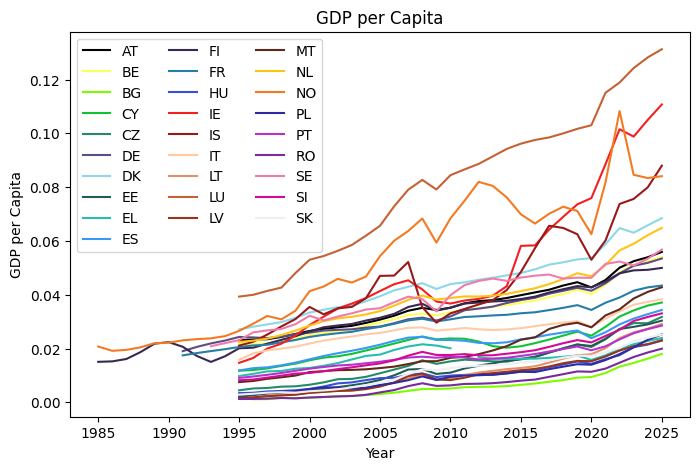

In [9]:
import matplotlib.pyplot as plt
from cycler import cycler

fig, ax = plt.subplots(figsize=(8,5))
colours = ['#000000', '#fcff5d', '#7dfc00', '#0ec434', '#228c68', '#5d4c86',
           '#8ad8e8', '#235b54', '#29bdab', '#3998f5', '#37294f', '#277da7',
           '#3750db', '#f22020', '#991919', '#ffcba5', '#e68f66', '#c56133',
           '#96341c', '#632819', '#ffc413', '#f47a22', '#2f2aa0', '#b732cc',
           '#772b9d', '#f07cab', '#d30b94', '#edeff3', '#c3a5b4', '#946aa2']
ax.set_prop_cycle(cycler(color=colours))
ax.plot(df_gdppc.T.set_index(df_gdppc.T.index.astype('int')), label=df_gdppc.index)
ax.legend(ncols=3)
ax.set_title('GDP per Capita')
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita')

In [10]:
#Join the life expectancy datasets to create single df for LE
df_le = df_le_1.copy()
df_le.index = df_le.index.set_levels(['Female LE from 0','Female LE from 65','Male LE from 0','Male LE from 65'],level=0)

df_le_add = df_le_2.loc[['F_LE_Y0', 'F_LE_Y65', 'M_LE_Y0', 'M_LE_Y65']].copy()
df_le_add.index = df_le_add.index.remove_unused_levels()
df_le_add.index = df_le_add.index.set_levels(['Female LE from 0','Female LE from 65','Male LE from 0','Male LE from 65'],level=0)

df_le = df_le.join(df_le_add)

Text(0, 0.5, 'Life Expectancy from Birth')

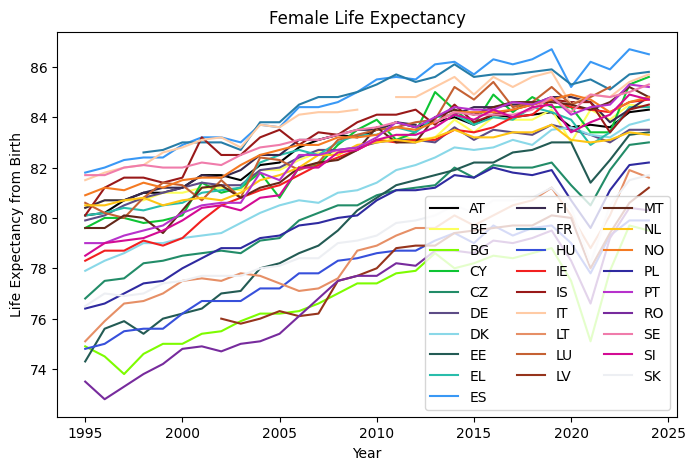

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
ax.set_prop_cycle(cycler(color=colours))
ax.plot(df_le.loc['Female LE from 0'].T.set_index(df_le.loc['Female LE from 0'].T.index.astype('int')), label=df_le.loc['Female LE from 0'].index)
ax.legend(ncols=3)
ax.set_title('Female Life Expectancy')
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy from Birth')

Text(0, 0.5, 'Life Expectancy from Birth')

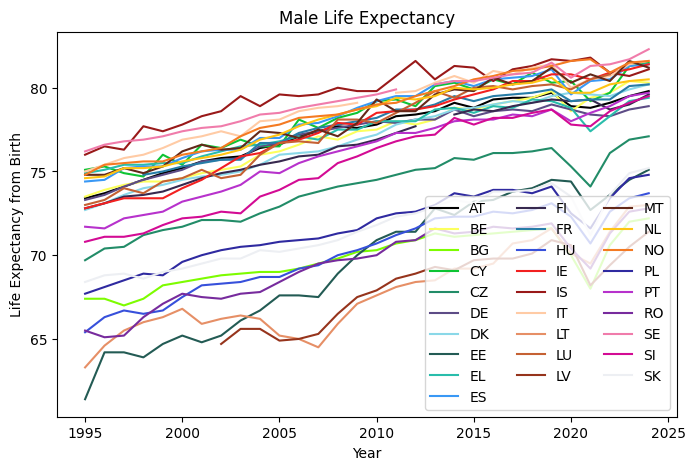

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
ax.set_prop_cycle(cycler(color=colours))
ax.plot(df_le.loc['Male LE from 0'].T.set_index(df_le.loc['Male LE from 0'].T.index.astype('int')), label=df_le.loc['Male LE from 0'].index)
ax.legend(ncols=3)
ax.set_title('Male Life Expectancy')
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy from Birth')

In [13]:
#Constructing pairs of (GDP,LE) to explore relationship
df = df_le.unstack('Region').T[['Female LE from 0', 'Male LE from 0']]
gdp = df_gdppc.unstack('Region')
gdp.rename('GDP per Capita', inplace=True)
df = df.join(gdp, how='outer')

Text(0.5, 0, 'GDP per Capita')

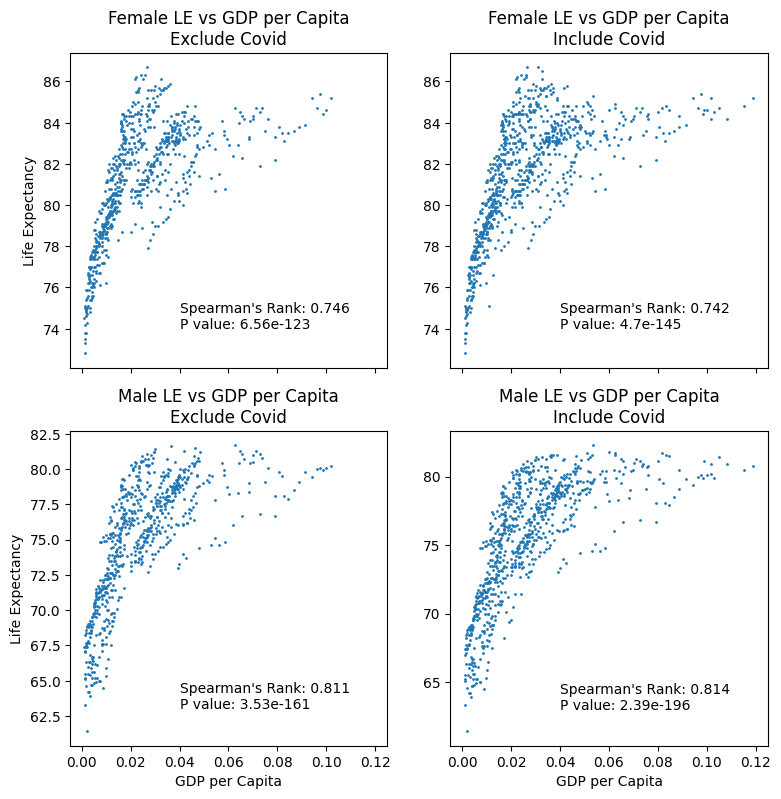

In [14]:
#Plotting data for men and women, and including/ommiting data from 2020 (i.e. check impact of Covid)
fig, axes = plt.subplots(2,2,sharex=True, figsize=(9,9))
axes[0,0].scatter(df.loc['1985':'2019']['GDP per Capita'],df.loc['1985':'2019']['Female LE from 0'],s=1)
axes[0,0].set_title('Female LE vs GDP per Capita\nExclude Covid')
axes[1,0].scatter(df.loc['1985':'2019']['GDP per Capita'],df.loc['1985':'2019']['Male LE from 0'],s=1)
axes[1,0].set_title('Male LE vs GDP per Capita\nExclude Covid')
axes[0,1].scatter(df['GDP per Capita'],df['Female LE from 0'],s=1)
axes[0,1].set_title('Female LE vs GDP per Capita\nInclude Covid')
axes[1,1].scatter(df['GDP per Capita'],df['Male LE from 0'],s=1)
axes[1,1].set_title('Male LE vs GDP per Capita\nInclude Covid')

#Adding Spearman rank coeffeicient along and p-value of significance test
import scipy as sp
res00 = sp.stats.spearmanrho(df.loc['1985':'2019']['Female LE from 0'], df.loc['1985':'2019']['GDP per Capita'],nan_policy='omit')
res10 = sp.stats.spearmanrho(df.loc['1985':'2019']['Male LE from 0'], df.loc['1985':'2019']['GDP per Capita'],nan_policy='omit')
res01 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita'],nan_policy='omit')
res11 = sp.stats.spearmanrho(df['Male LE from 0'], df['GDP per Capita'],nan_policy='omit')

axes[0,0].text(0.04,74,f'Spearman\'s Rank: {res00[0]:.3}\nP value: {res00[1]:.3}')
axes[0,1].text(0.04,74,f'Spearman\'s Rank: {res01[0]:.3}\nP value: {res01[1]:.3}')
axes[1,0].text(0.04,63,f'Spearman\'s Rank: {res10[0]:.3}\nP value: {res10[1]:.3}')
axes[1,1].text(0.04,63,f'Spearman\'s Rank: {res11[0]:.3}\nP value: {res11[1]:.3}')

axes[0,0].set_ylabel('Life Expectancy')
axes[1,0].set_ylabel('Life Expectancy')
axes[1,0].set_xlabel('GDP per Capita')
axes[1,1].set_xlabel('GDP per Capita')

This first set of plots and associated Spearman's rank correlation coefficients show a strong but non-linear positive correlation between life expectancy and GDP per capita. 

Also note that the inclusion or exclusion of the years from the outbreak of the Covid epidemic onwards, 2020, make little impact either on the appearance of the plot or the correlation coefficient.

The above analysis ignores all time series aspects of the datasets, treating each region-year pair as separate data points.

Text(0.5, 0, 'GDP per Capita')

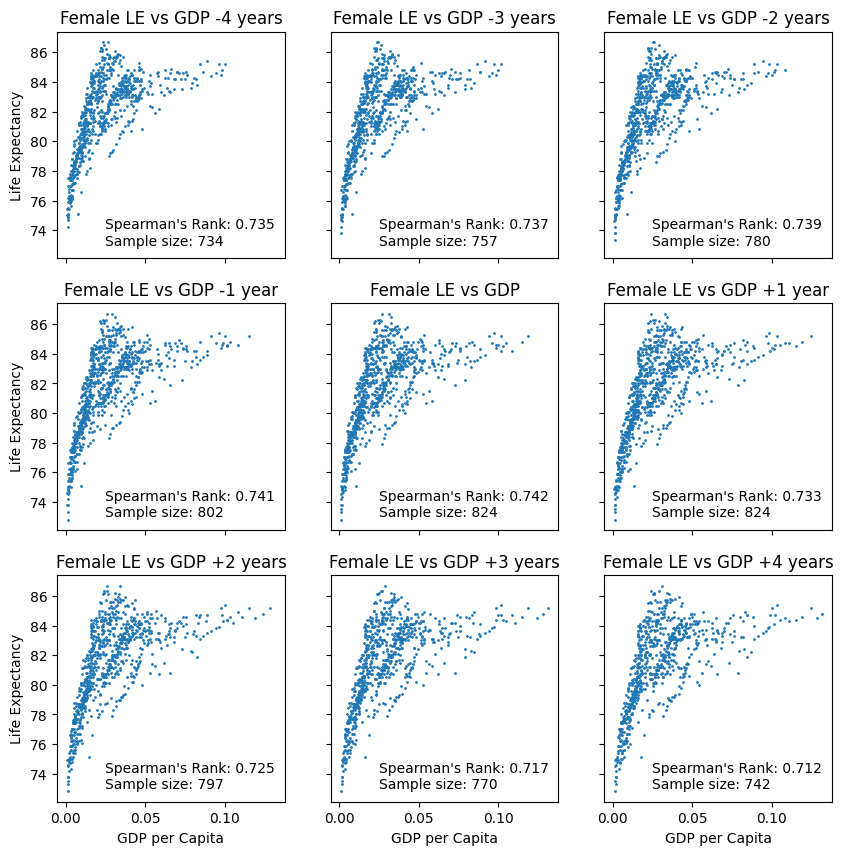

In [15]:
#Compare LE to time shifted GDP, looking to see what effect a time delay has on the correlation
import numpy as np

df['GDP per Capita - 1'] = [np.nan for i in range(28)] + list(df['GDP per Capita'])[:-28]
df['GDP per Capita - 2'] = [np.nan for i in range(28)] + list(df['GDP per Capita - 1'])[:-28]
df['GDP per Capita - 3'] = [np.nan for i in range(28)] + list(df['GDP per Capita - 2'])[:-28]
df['GDP per Capita - 4'] = [np.nan for i in range(28)] + list(df['GDP per Capita - 3'])[:-28]

df['GDP per Capita + 1'] = list(df['GDP per Capita'])[28:] + [np.nan for i in range(28)]
df['GDP per Capita + 2'] = list(df['GDP per Capita + 1'])[28:] + [np.nan for i in range(28)]
df['GDP per Capita + 3'] = list(df['GDP per Capita + 2'])[28:] + [np.nan for i in range(28)]
df['GDP per Capita + 4'] = list(df['GDP per Capita + 3'])[28:] + [np.nan for i in range(28)]

#Plotting all shifted versions
fig, axes = plt.subplots(3,3,sharex=True,sharey=True, figsize=(10,10))
axes[0,0].scatter(df['GDP per Capita - 4'],df['Female LE from 0'],s=1)
axes[0,0].set_title('Female LE vs GDP -4 years')
axes[0,1].scatter(df['GDP per Capita - 3'],df['Female LE from 0'],s=1)
axes[0,1].set_title('Female LE vs GDP -3 years')
axes[0,2].scatter(df['GDP per Capita - 2'],df['Female LE from 0'],s=1)
axes[0,2].set_title('Female LE vs GDP -2 years')
axes[1,0].scatter(df['GDP per Capita - 1'],df['Female LE from 0'],s=1)
axes[1,0].set_title('Female LE vs GDP -1 year')
axes[1,1].scatter(df['GDP per Capita'],df['Female LE from 0'],s=1)
axes[1,1].set_title('Female LE vs GDP')
axes[1,2].scatter(df['GDP per Capita + 1'],df['Female LE from 0'],s=1)
axes[1,2].set_title('Female LE vs GDP +1 year')
axes[2,0].scatter(df['GDP per Capita + 2'],df['Female LE from 0'],s=1)
axes[2,0].set_title('Female LE vs GDP +2 years')
axes[2,1].scatter(df['GDP per Capita + 3'],df['Female LE from 0'],s=1)
axes[2,1].set_title('Female LE vs GDP +3 years')
axes[2,2].scatter(df['GDP per Capita + 4'],df['Female LE from 0'],s=1)
axes[2,2].set_title('Female LE vs GDP +4 years')

#Adding Spearman's rank coefficients and sample sizes
r00 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita - 4'],nan_policy='omit').statistic
r01 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita - 3'],nan_policy='omit').statistic
r02 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita - 2'],nan_policy='omit').statistic
r10 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita - 1'],nan_policy='omit').statistic
r11 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita'],nan_policy='omit').statistic
r12 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita + 1'],nan_policy='omit').statistic
r20 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita + 2'],nan_policy='omit').statistic
r21 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita + 3'],nan_policy='omit').statistic
r22 = sp.stats.spearmanrho(df['Female LE from 0'], df['GDP per Capita + 4'],nan_policy='omit').statistic

s00 = sum(df['Female LE from 0'].notna() & df['GDP per Capita - 4'].notna())
s01 = sum(df['Female LE from 0'].notna() & df['GDP per Capita - 3'].notna())
s02 = sum(df['Female LE from 0'].notna() & df['GDP per Capita - 2'].notna())
s10 = sum(df['Female LE from 0'].notna() & df['GDP per Capita - 1'].notna())
s11 = sum(df['Female LE from 0'].notna() & df['GDP per Capita'].notna())
s12 = sum(df['Female LE from 0'].notna() & df['GDP per Capita + 1'].notna())
s20 = sum(df['Female LE from 0'].notna() & df['GDP per Capita + 2'].notna())
s21 = sum(df['Female LE from 0'].notna() & df['GDP per Capita + 3'].notna())
s22 = sum(df['Female LE from 0'].notna() & df['GDP per Capita + 4'].notna())

axes[0,0].text(0.025,73,f'Spearman\'s Rank: {r00:.3}\nSample size: {s00}')
axes[0,1].text(0.025,73,f'Spearman\'s Rank: {r01:.3}\nSample size: {s01}')
axes[0,2].text(0.025,73,f'Spearman\'s Rank: {r02:.3}\nSample size: {s02}')
axes[1,0].text(0.025,73,f'Spearman\'s Rank: {r10:.3}\nSample size: {s10}')
axes[1,1].text(0.025,73,f'Spearman\'s Rank: {r11:.3}\nSample size: {s11}')
axes[1,2].text(0.025,73,f'Spearman\'s Rank: {r12:.3}\nSample size: {s12}')
axes[2,0].text(0.025,73,f'Spearman\'s Rank: {r20:.3}\nSample size: {s20}')
axes[2,1].text(0.025,73,f'Spearman\'s Rank: {r21:.3}\nSample size: {s21}')
axes[2,2].text(0.025,73,f'Spearman\'s Rank: {r22:.3}\nSample size: {s22}')

axes[0,0].set_ylabel('Life Expectancy')
axes[1,0].set_ylabel('Life Expectancy')
axes[2,0].set_ylabel('Life Expectancy')
axes[2,0].set_xlabel('GDP per Capita')
axes[2,1].set_xlabel('GDP per Capita')
axes[2,2].set_xlabel('GDP per Capita')

From this plot, it seems that the correlation is not substantially affected by adding a delayed effect, with in fact the greatest correlation coefficient being with the unshifted data. It is not unsurprising that the effect is small, as the shifted datasets are highly correlated, but perhaps interesting that if the assertion is that GDP per capita affects life expectancy, there isn't, by this simple and crude measure, much delay in this effect.

It is also perhaps worth noting that the correlation when the life expectancy proceeds the GDP is weaker than the other way around.

Note that there is some variation in the sample sizes across these different plots ranging from 734 to 824. 

In [16]:
#Looking at the sparse data points at high GDP per capita
high_gdp = df.sort_values('GDP per Capita',ascending=False).head(50)
high_gdp.index.get_level_values(1).value_counts()

Region
LU    20
NO    16
IE     8
IS     4
DK     2
Name: count, dtype: int64

From this, we see that LU (Luxembourg) and NO (Norway) dominate the high gdp part of the dataset.

Text(0, 0.5, 'Life Expectancy')

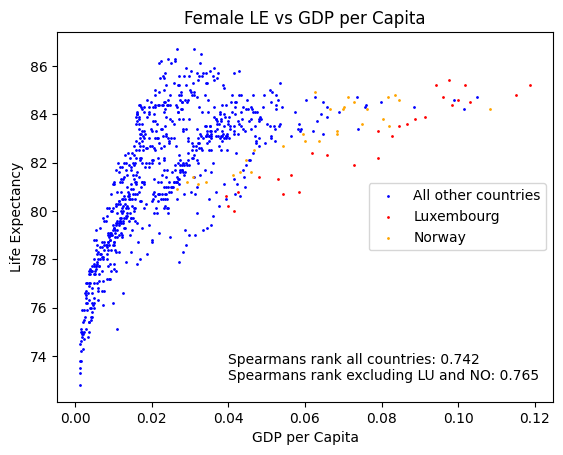

In [17]:
#Showing LU and NO on scatter plot, and plotting and computing correlation with them removed
all_reg = set(df.index.levels[1])
other_reg = list(all_reg - set(['LU','NO']))
fig, ax = plt.subplots()
ax.scatter(df.loc[pd.IndexSlice[:, other_reg], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, other_reg], :]['Female LE from 0'],s=1,color='blue',label='All other countries')
ax.scatter(df.loc[pd.IndexSlice[:, 'LU'], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, 'LU'], :]['Female LE from 0'],s=1,color='red',label='Luxembourg')
ax.scatter(df.loc[pd.IndexSlice[:, 'NO'], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, 'NO'], :]['Female LE from 0'],s=1,color='orange',label='Norway')
ax.legend()

r_other = sp.stats.spearmanrho(df.loc[pd.IndexSlice[:, other_reg], :]['GDP per Capita'], df.loc[pd.IndexSlice[:, other_reg], :]['Female LE from 0'],nan_policy='omit').statistic
r_all = sp.stats.spearmanrho(df['GDP per Capita'], df['Female LE from 0'], nan_policy='omit').statistic
ax.text(0.04,73,f'Spearmans rank all countries: {r_all:.3}\nSpearmans rank excluding LU and NO: {r_other:.3}')
ax.set_title('Female LE vs GDP per Capita')
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Life Expectancy')

Removing these countries does improve the correlation somewhat, but it is important not to get carried away removing examples to make the fit better. Likely it indicates that the measure GDP per Capita is not well suited for these countries (perhaps due to large corporate revenues for Luxembourg and oil/gas for Norway not reflecting conditions for residents/healthcare spending?).

In [18]:
#Looking at analagous data for high LE countries
high_le = df.sort_values('Female LE from 0',ascending=False).head(50)
high_le.index.get_level_values(1).value_counts()

Region
ES    16
FR    16
IT     8
LU     4
CY     2
PT     2
SE     1
MT     1
Name: count, dtype: int64

This shows that high LE is dominated by ES (Spain) and FR (France), and to a slightly lesser extent IT (Italy)

Text(0, 0.5, 'Life Expectancy')

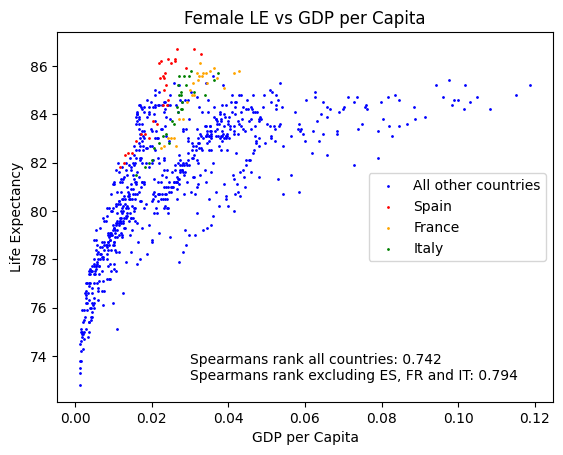

In [19]:
#Showing ES, FR and IT on scatter plot, and plotting and computing correlation with them removed
all_reg = set(df.index.levels[1])
other_reg = list(all_reg - set(['ES','FR','IT']))
fig, ax = plt.subplots()
ax.scatter(df.loc[pd.IndexSlice[:, other_reg], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, other_reg], :]['Female LE from 0'],s=1,color='blue',label='All other countries')
ax.scatter(df.loc[pd.IndexSlice[:, 'ES'], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, 'ES'], :]['Female LE from 0'],s=1,color='red',label='Spain')
ax.scatter(df.loc[pd.IndexSlice[:, 'FR'], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, 'FR'], :]['Female LE from 0'],s=1,color='orange',label='France')
ax.scatter(df.loc[pd.IndexSlice[:, 'IT'], :]['GDP per Capita'],df.loc[pd.IndexSlice[:, 'IT'], :]['Female LE from 0'],s=1,color='green',label='Italy')
ax.legend()

r_other = sp.stats.spearmanrho(df.loc[pd.IndexSlice[:, other_reg], :]['GDP per Capita'], df.loc[pd.IndexSlice[:, other_reg], :]['Female LE from 0'],nan_policy='omit').statistic
r_all = sp.stats.spearmanrho(df['GDP per Capita'], df['Female LE from 0'], nan_policy='omit').statistic
ax.text(0.03,73,f'Spearmans rank all countries: {r_all:.3}\nSpearmans rank excluding ES, FR and IT: {r_other:.3}')

ax.set_title('Female LE vs GDP per Capita')
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Life Expectancy')

As before, excluding these high LE countries does improve the correlation, but this doesn't seem to be from removing visually outlying points as in the previous case. This is perhaps an indication that a different variable or a further variable is needed to improve the understanding of this relationship. 

For example, looking at each specific country, Spain's data for example follows quite a clean linear relationship with a relatively steep gradient, whereas Luxembourg also follows a relatively linear path but with a much shallower slope.

In [20]:
#Looking at different GDP dataset, based on only household expendature
#Data from https://doi.org/10.2908/NAMA_10_PC
df_gdp_h = pd.read_csv('gdp_household_expendature.tsv', delimiter='\t')

#Recover relevant index, namely region, from first column
indices = list(df_gdp_h[r'freq,unit,na_item,geo\TIME_PERIOD'])
regions = []
for i in indices:
    regions.append(i.split(',')[-1])
    
df_gdp_h['Region'] = regions
df_gdp_h.set_index('Region', inplace=True)
df_gdp_h.drop(r'freq,unit,na_item,geo\TIME_PERIOD', axis=1, inplace=True)
df_gdp_h.head(10)

,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
AL,:,:,:,:,:,:,:,:,:,:,...,18733.8,19121.2,19593.1,20497.3,19384.9,20480.1,23628.0,25954.1,27437.6 p,:
AT,:,:,:,:,:,:,:,:,:,:,...,159318.4,163867.9,168602.7,171607.1,158833.0,171176.1,197571.1,210021.5,217525.3,223688.6
BA,:,:,:,:,:,:,:,:,:,:,...,24430.1,24571.4,25260.7,25951.7,25027.9,26113.0,29205.9,31992.6,33925.1,35317.1
BE,:,:,:,:,:,:,:,:,:,:,...,195426.6,202378.0,209641.0,215512.0,203553.9,219084.7,250847.3,270520.8,281412.3 p,290545.2 p
BG,:,:,:,:,:,:,:,:,:,:,...,59523.4,62242.3,64549.7,67440.3,65889.5,73877.8,83278.6,89420.7,96440.4,105675.4 p
CY,:,:,:,:,:,:,:,:,:,:,...,13686.4,14493.0,15442.3,16164.8,14954.5,15648.7,18426.3,20441.2,21648.7 p,22567.3 p
CZ,:,:,:,:,:,:,:,:,:,:,...,127556.9,137265.9,144723.3,150475.3,141532.8,148329.8,166171.7,176250.1,183681.0,194303.3
DE,:,:,:,:,:,:,:,:,:,:,...,1524536.7,1571503.3,1620572.2,1643492.5,1532448.2,1613410.2,1825806.6 p,1923967.1 p,1988050.0 p,2066600.9 p
DK,:,:,:,:,:,:,:,:,:,:,...,94397.4,99867.1,104450.4,106322.2,105982.1,115435.6,121133.6,124850.6,128435.7,134824.5


In [21]:
#Cleaning dataset
df_gdp_h = df_gdp_h.map(lambda x : str(x).split(' ')[0])
df_gdp_h[df_gdp_h == ':'] = pd.NA
df_gdp_h.rename(lambda x : x.strip(), axis='columns', inplace=True)
df_gdp_h = df_gdp_h.astype('float')

remove = set(df_gdp_h.index) - set(df.index.levels[1])
for i in remove:
    df_gdp_h.drop(index=i, inplace=True)

df_gdp_h.drop(['1975','1976','1977','1978','1979','1980','1981','1982','1983','1984'],axis=1, inplace=True)

Text(0, 0.5, 'Household Expenditure GDP per Capita')

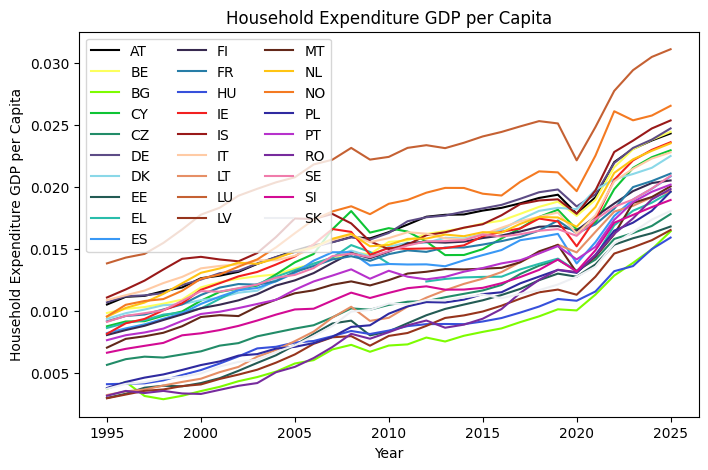

In [22]:
#Normalising by population
df_gdp_h_pc = df_gdp_h/df_pop.loc['TOTAL_T']
fig, ax = plt.subplots(figsize=(8,5))

ax.set_prop_cycle(cycler(color=colours))
ax.plot(df_gdp_h_pc.T.set_index(df_gdp_h_pc.T.index.astype('int')), label=df_gdp_h_pc.index)
ax.legend(ncols=3)
ax.set_title('Household Expenditure GDP per Capita')
ax.set_xlabel('Year')
ax.set_ylabel('Household Expenditure GDP per Capita')

In [23]:
#Adding to df and plotting against LE
gdp_h = df_gdp_h_pc.unstack('Region')
gdp_h.rename('Household Expenditure GDP per Capital', inplace=True)
df = df.join(gdp_h, how='outer')

Text(0.5, 0, 'Household Expenditure GDP per Capita')

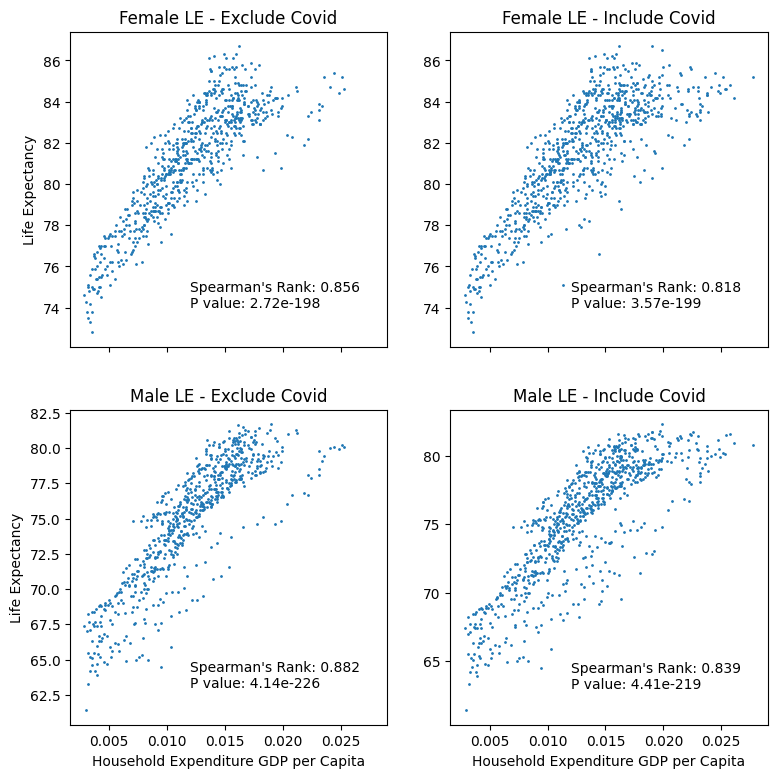

In [24]:
#Plotting data for men and women, and including/ommiting data from 2020 (i.e. check impact of Covid)
fig, axes = plt.subplots(2,2,sharex=True, figsize=(9,9))
axes[0,0].scatter(df.loc['1985':'2019']['Household Expenditure GDP per Capital'],df.loc['1985':'2019']['Female LE from 0'],s=1)
axes[0,0].set_title('Female LE - Exclude Covid')
axes[1,0].scatter(df.loc['1985':'2019']['Household Expenditure GDP per Capital'],df.loc['1985':'2019']['Male LE from 0'],s=1)
axes[1,0].set_title('Male LE - Exclude Covid')
axes[0,1].scatter(df['Household Expenditure GDP per Capital'],df['Female LE from 0'],s=1)
axes[0,1].set_title('Female LE - Include Covid')
axes[1,1].scatter(df['Household Expenditure GDP per Capital'],df['Male LE from 0'],s=1)
axes[1,1].set_title('Male LE - Include Covid')

#Adding Spearman rank coeffeicient along and p-value of significance test
res00 = sp.stats.spearmanrho(df.loc['1985':'2019']['Female LE from 0'], df.loc['1985':'2019']['Household Expenditure GDP per Capital'],nan_policy='omit')
res10 = sp.stats.spearmanrho(df.loc['1985':'2019']['Male LE from 0'], df.loc['1985':'2019']['Household Expenditure GDP per Capital'],nan_policy='omit')
res01 = sp.stats.spearmanrho(df['Female LE from 0'], df['Household Expenditure GDP per Capital'],nan_policy='omit')
res11 = sp.stats.spearmanrho(df['Male LE from 0'], df['Household Expenditure GDP per Capital'],nan_policy='omit')

axes[0,0].text(0.012,74,f'Spearman\'s Rank: {res00[0]:.3}\nP value: {res00[1]:.3}')
axes[0,1].text(0.012,74,f'Spearman\'s Rank: {res01[0]:.3}\nP value: {res01[1]:.3}')
axes[1,0].text(0.012,63,f'Spearman\'s Rank: {res10[0]:.3}\nP value: {res10[1]:.3}')
axes[1,1].text(0.012,63,f'Spearman\'s Rank: {res11[0]:.3}\nP value: {res11[1]:.3}')

axes[0,0].set_ylabel('Life Expectancy')
axes[1,0].set_ylabel('Life Expectancy')
axes[1,0].set_xlabel('Household Expenditure GDP per Capita')
axes[1,1].set_xlabel('Household Expenditure GDP per Capita')

This shows that household expenditure better correlates with LE than total GDP, and gives much cleaner linear looking relationships. 

Including data from 2020 makes slightly more impact than before, but is not so far outlying as to need exclusion.

Text(0.5, 0, 'Household Expenditure GDP per Capita')

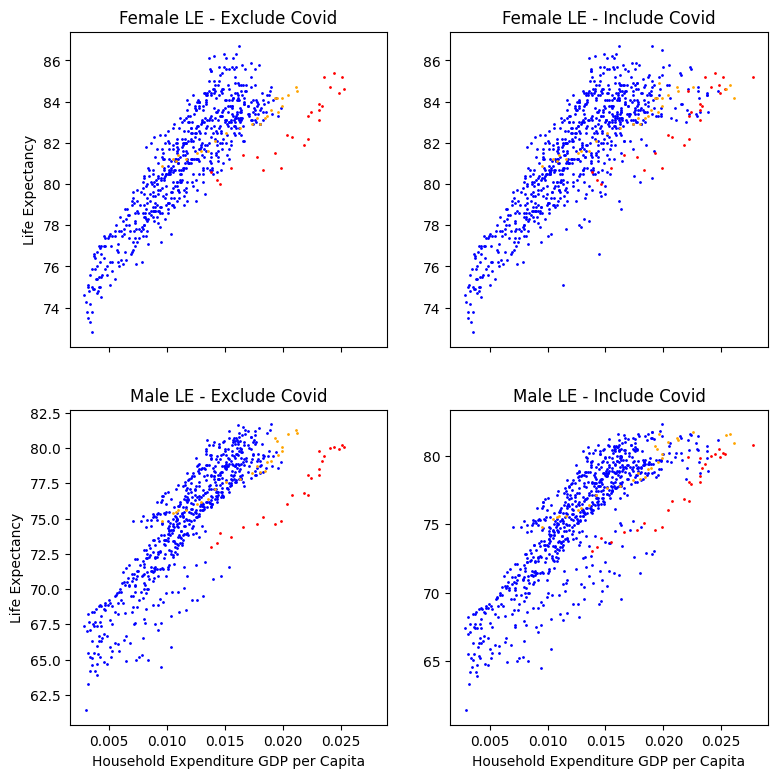

In [25]:
#Checking where the previous outliers of LU and NO lie wrt this new measure
all_reg = set(df.index.levels[1])
other_reg = list(all_reg - set(['LU','NO']))

fig, axes = plt.subplots(2,2,sharex=True, figsize=(9,9))
axes[0,0].scatter(df.loc[pd.IndexSlice['1985':'2019', other_reg], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice['1985':'2019', other_reg], :]['Female LE from 0'],s=1,color='blue',label='All other countries')
axes[0,0].scatter(df.loc[pd.IndexSlice['1985':'2019', 'LU'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice['1985':'2019', 'LU'], :]['Female LE from 0'],s=1,color='red',label='Luxumbourg')
axes[0,0].scatter(df.loc[pd.IndexSlice['1985':'2019', 'NO'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice['1985':'2019', 'NO'], :]['Female LE from 0'],s=1,color='orange',label='Norway')
axes[0,0].set_title('Female LE - Exclude Covid')
axes[1,0].scatter(df.loc[pd.IndexSlice['1985':'2019', other_reg], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice['1985':'2019', other_reg], :]['Male LE from 0'],s=1,color='blue',label='All other countries')
axes[1,0].scatter(df.loc[pd.IndexSlice['1985':'2019', 'LU'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice['1985':'2019', 'LU'], :]['Male LE from 0'],s=1,color='red',label='Luxembourg')
axes[1,0].scatter(df.loc[pd.IndexSlice['1985':'2019', 'NO'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice['1985':'2019', 'NO'], :]['Male LE from 0'],s=1,color='orange',label='Norway')
axes[1,0].set_title('Male LE - Exclude Covid')
axes[0,1].scatter(df.loc[pd.IndexSlice[:, other_reg], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice[:, other_reg], :]['Female LE from 0'],s=1,color='blue',label='All other countries')
axes[0,1].scatter(df.loc[pd.IndexSlice[:, 'LU'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice[:, 'LU'], :]['Female LE from 0'],s=1,color='red',label='Luxembourg')
axes[0,1].scatter(df.loc[pd.IndexSlice[:, 'NO'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice[:, 'NO'], :]['Female LE from 0'],s=1,color='orange',label='Norway')
axes[0,1].set_title('Female LE - Include Covid')
axes[1,1].scatter(df.loc[pd.IndexSlice[:, other_reg], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice[:, other_reg], :]['Male LE from 0'],s=1,color='blue',label='All other countries')
axes[1,1].scatter(df.loc[pd.IndexSlice[:, 'LU'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice[:, 'LU'], :]['Male LE from 0'],s=1,color='red',label='Luxembourg')
axes[1,1].scatter(df.loc[pd.IndexSlice[:, 'NO'], :]['Household Expenditure GDP per Capital'],df.loc[pd.IndexSlice[:, 'NO'], :]['Male LE from 0'],s=1,color='orange',label='Norway')
axes[1,1].set_title('Male LE - Include Covid')

axes[0,0].set_ylabel('Life Expectancy')
axes[1,0].set_ylabel('Life Expectancy')
axes[1,0].set_xlabel('Household Expenditure GDP per Capita')
axes[1,1].set_xlabel('Household Expenditure GDP per Capita')

With this new GDP measure, Norway lies firmly in the normal part of the graph, though Luxembourg remains something of an outsider.

Text(0.5, 0, 'Household Expenditure GDP per Capita')

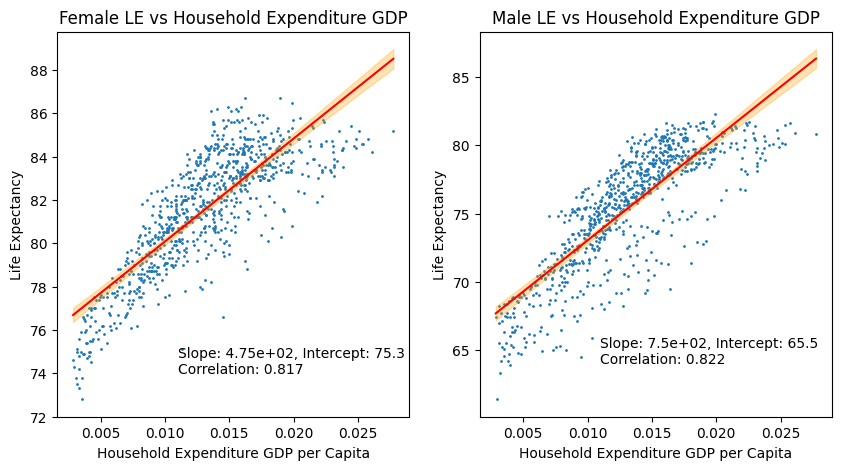

In [26]:
#As these plots indicate that a linear relationship is reasonable, now do linear regression analysis
fig, axes = plt.subplots(1,2,sharex=True, figsize=(10,5))
axes[0].scatter(df['Household Expenditure GDP per Capital'],df['Female LE from 0'],s=1)
axes[0].set_title('Female LE vs Household Expenditure GDP')
axes[1].scatter(df['Household Expenditure GDP per Capital'],df['Male LE from 0'],s=1)
axes[1].set_title('Male LE vs Household Expenditure GDP')

#masks for valid entries (both not being nan)
mask = df['Household Expenditure GDP per Capital'].notna() & df['Female LE from 0'].notna() & df['Male LE from 0'].notna()

#Add linear regression line
lin_f = sp.stats.linregress(df.loc[mask]['Household Expenditure GDP per Capital'],df.loc[mask]['Female LE from 0'],nan_policy='omit')
lin_m = sp.stats.linregress(df.loc[mask]['Household Expenditure GDP per Capital'],df.loc[mask]['Male LE from 0'],nan_policy='omit')

x = np.array(df.loc[mask]['Household Expenditure GDP per Capital'])
order = np.argsort(x)
x_mean = np.mean(x)
y_f_est = lin_f.intercept + lin_f.slope*x
axes[0].plot(x[order],y_f_est[order],color='red')

y_m_est = lin_m.intercept + lin_m.slope*x
axes[1].plot(x[order],y_m_est[order],color='red')

axes[0].text(0.011,74,f'Slope: {lin_f.slope:.3}, Intercept: {lin_f.intercept:.3}\nCorrelation: {lin_f.rvalue:.3}')
axes[1].text(0.011,64,f'Slope: {lin_m.slope:.3}, Intercept: {lin_m.intercept:.3}\nCorrelation: {lin_m.rvalue:.3}')

#Compute Working–Hotelling 95% error band
n_f = sum(df['Household Expenditure GDP per Capital'].notna() & df['Female LE from 0'].notna())
n_m = sum(df['Household Expenditure GDP per Capital'].notna() & df['Male LE from 0'].notna())

W_f = 2*sp.stats.f.isf(0.05,2,n_f-2)
W_m = 2*sp.stats.f.isf(0.05,2,n_m-2)

s_f = (1/(n_f - 2)) * np.sum(np.power(y_f_est - np.array(df.loc[mask]['Female LE from 0']),2))
s_m = (1/(n_f - 2)) * np.sum(np.power(y_m_est - np.array(df.loc[mask]['Male LE from 0']),2))

h_f = 1/n_f + np.power(x - x_mean,2)/np.sum(np.power(x - x_mean,2))
h_m = 1/n_m + np.power(x - x_mean,2)/np.sum(np.power(x - x_mean,2))

e_f = np.sqrt(W_f*s_f*h_f)
e_m = np.sqrt(W_m*s_m*h_m)


axes[0].fill_between(x[order], (y_f_est - e_f)[order], (y_f_est + e_f)[order], color='orange', alpha=0.3)
axes[1].fill_between(x[order], (y_m_est - e_m)[order], (y_m_est + e_m)[order], color='orange', alpha=0.3)

axes[0].set_ylabel('Life Expectancy')
axes[1].set_ylabel('Life Expectancy')
axes[0].set_xlabel('Household Expenditure GDP per Capita')
axes[1].set_xlabel('Household Expenditure GDP per Capita')

Text(0, 0.5, 'Residual LE')

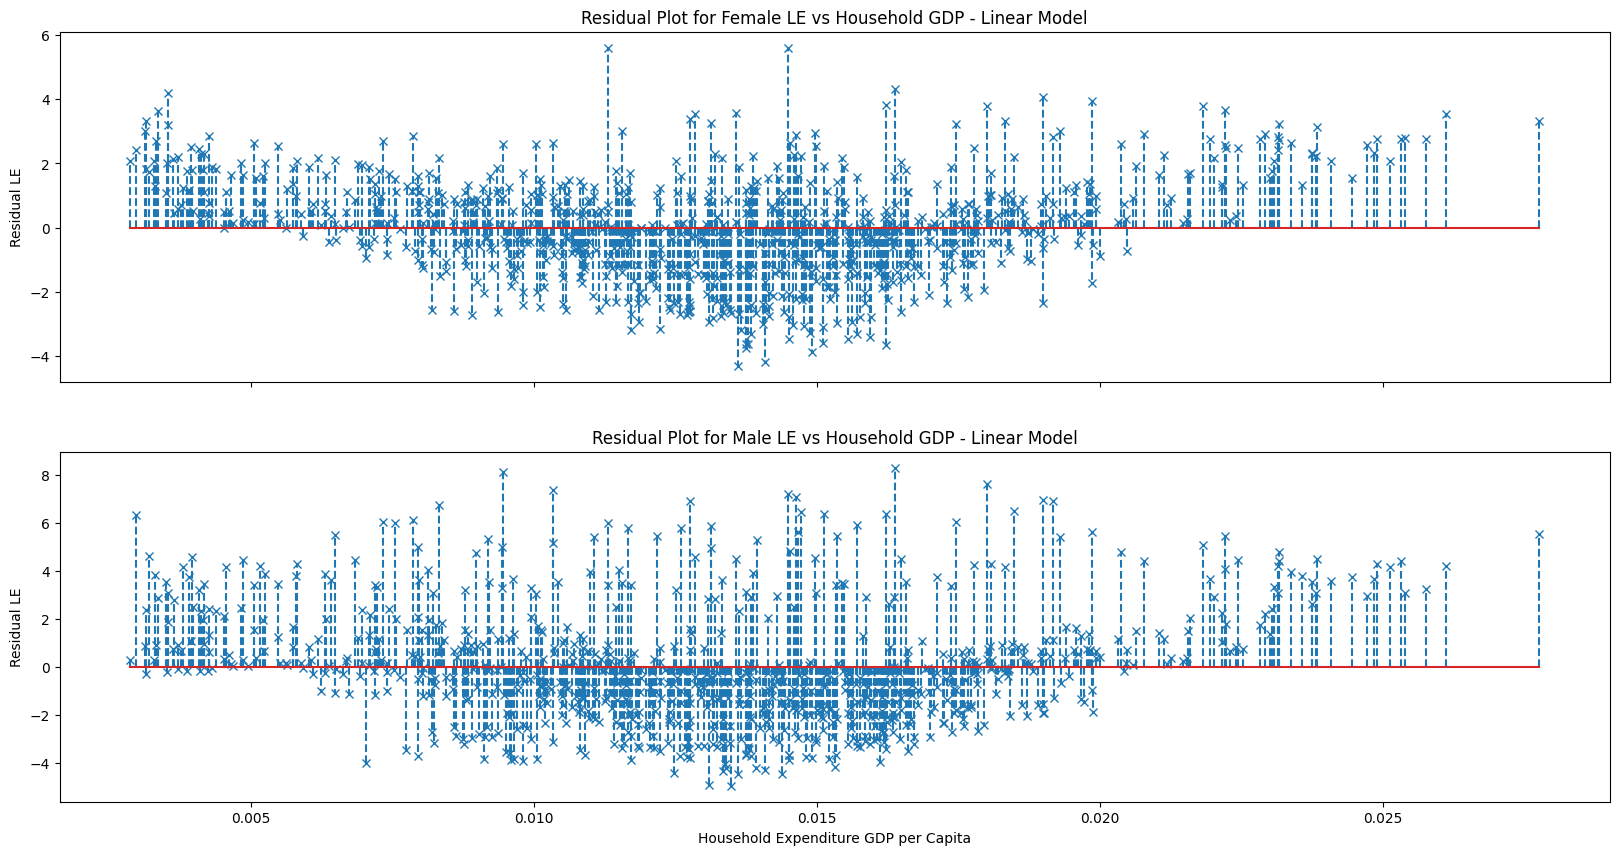

In [27]:
#Plotting residuals
fig, axes = plt.subplots(2,1,figsize=(20,10),sharex=True)
axes[0].stem(x,y_f_est - np.array(df.loc[mask]['Female LE from 0']),linefmt='--',markerfmt='x')
axes[1].stem(x,y_m_est - np.array(df.loc[mask]['Male LE from 0']),linefmt='--',markerfmt='x')

axes[0].set_title('Residual Plot for Female LE vs Household GDP - Linear Model')
axes[1].set_title('Residual Plot for Male LE vs Household GDP - Linear Model')

axes[1].set_xlabel('Household Expenditure GDP per Capita')
axes[0].set_ylabel('Residual LE')
axes[1].set_ylabel('Residual LE')

There is clearly structure to the residual plot, hence the assumptions of the linear model are not properly met. Looking at the shape of residuals, a natural seeming next step is to consider a quadratic fit.

In [28]:
#Fitting quadratic curve to data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

#X = np.array(df.loc[mask]['Household Expenditure GDP per Capital'])
model = Pipeline([('poly', PolynomialFeatures(degree=2)),
                  ('linear', LinearRegression(fit_intercept=False))])

X = np.array(df.loc[mask]['Household Expenditure GDP per Capital']).reshape(-1,1)

model.fit(X,df.loc[mask]['Female LE from 0'])
coef_f = model.named_steps['linear'].coef_

model.fit(X,df.loc[mask]['Male LE from 0'])
coef_m = model.named_steps['linear'].coef_

Text(0.5, 0, 'Household Expenditure GDP per Capita')

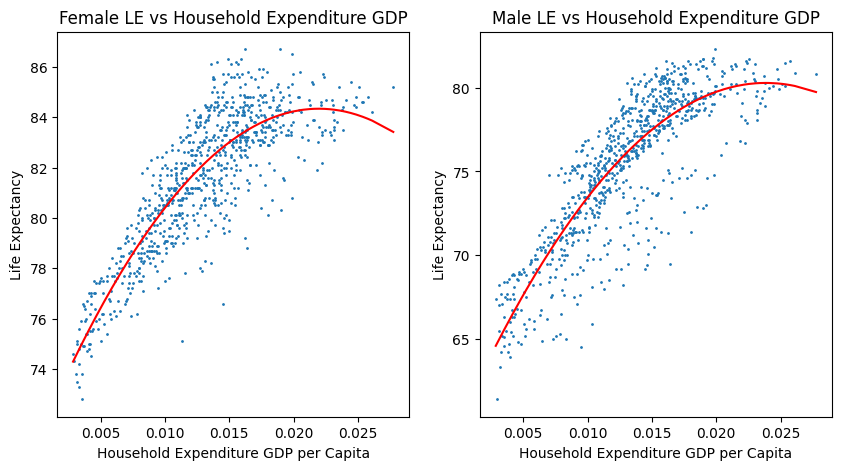

In [29]:
fig, axes = plt.subplots(1,2,sharex=True, figsize=(10,5))
axes[0].scatter(df['Household Expenditure GDP per Capital'],df['Female LE from 0'],s=1)
axes[0].set_title('Female LE vs Household Expenditure GDP')
axes[1].scatter(df['Household Expenditure GDP per Capital'],df['Male LE from 0'],s=1)
axes[1].set_title('Male LE vs Household Expenditure GDP')

#Add quadratic regression line

order = np.argsort(np.ravel(X))
y_f_est = np.polyval(np.flip(coef_f),np.ravel(X))
#coef_f[0] + coef_f[1]*np.ravel(X) + coef_f[2]*(np.ravel(X)**2)
axes[0].plot(np.ravel(X)[order],y_f_est[order],color='red')

y_m_est = np.polyval(np.flip(coef_m),np.ravel(X))
axes[1].plot(np.ravel(X)[order],y_m_est[order],color='red')

axes[0].set_ylabel('Life Expectancy')
axes[1].set_ylabel('Life Expectancy')
axes[0].set_xlabel('Household Expenditure GDP per Capita')
axes[1].set_xlabel('Household Expenditure GDP per Capita')

Text(0, 0.5, 'Residual LE')

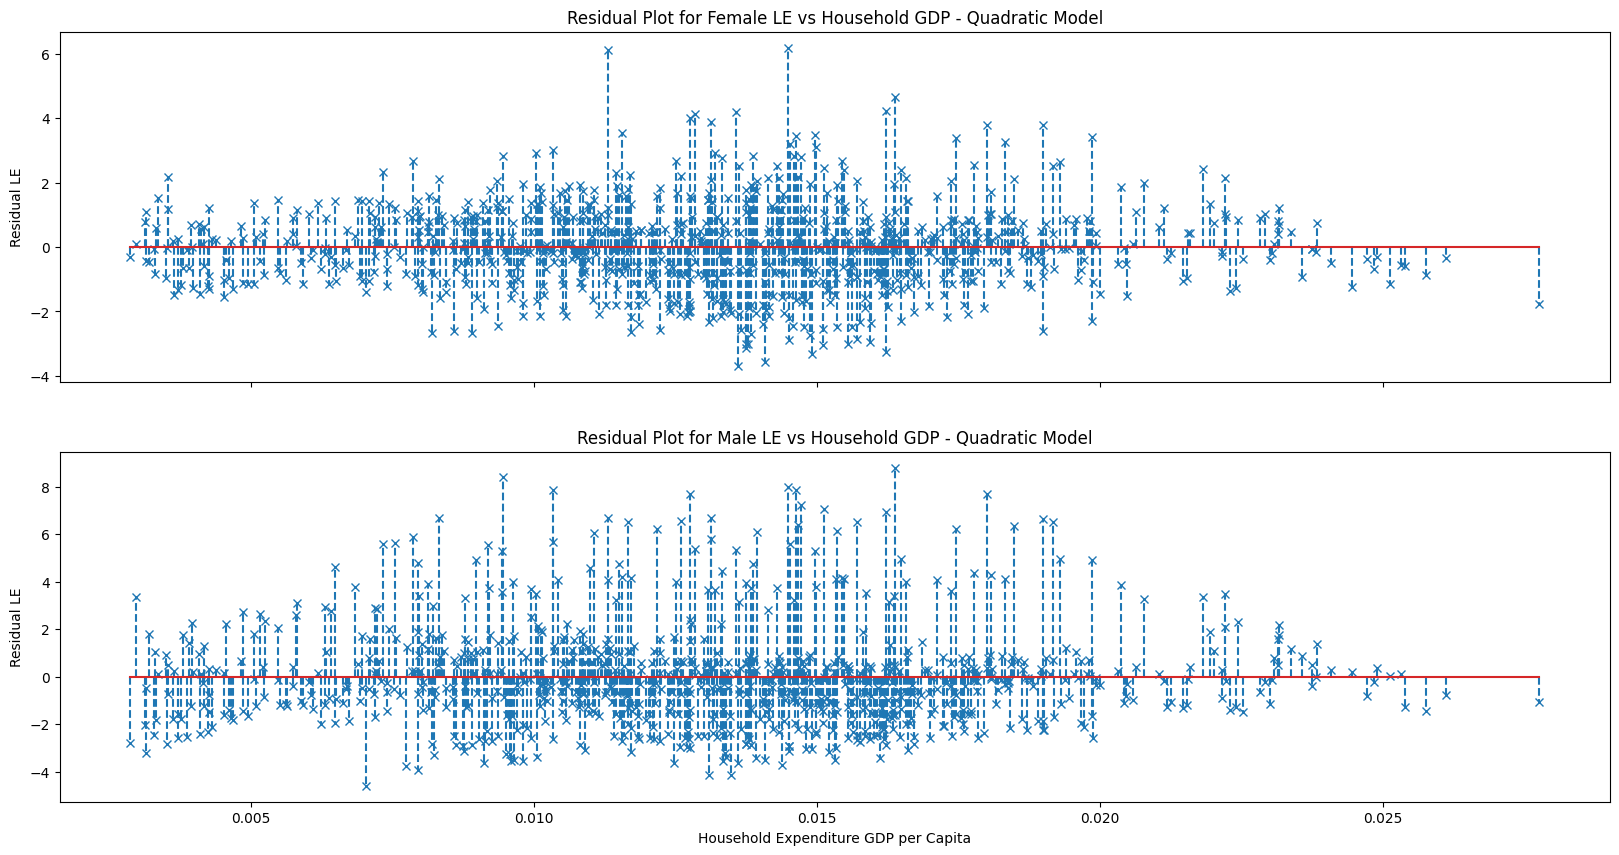

In [30]:
#Plotting residuals
fig, axes = plt.subplots(2,1,figsize=(20,10), sharex=True)
axes[0].stem(np.ravel(X),y_f_est - np.array(df.loc[mask]['Female LE from 0']),linefmt='--',markerfmt='x')
axes[1].stem(np.ravel(X),y_m_est - np.array(df.loc[mask]['Male LE from 0']),linefmt='--',markerfmt='x')
axes[0].set_title('Residual Plot for Female LE vs Household GDP - Quadratic Model')
axes[1].set_title('Residual Plot for Male LE vs Household GDP - Quadratic Model')

axes[1].set_xlabel('Household Expenditure GDP per Capita')
axes[0].set_ylabel('Residual LE')
axes[1].set_ylabel('Residual LE')

The above plots of the fitted quadratic models and the residual plots show a better fit than the linear model, and the residuals exhibit much less structure than before.

In [31]:
#Computing using bootstrap a confidence band for the quadratic model. 
#It is possible to repeat the Working–Hotelling procedure, but I wanted to experiment with bootstrap here.
#Moreover this doesn't make parametric assumptions.

import random
n_sample = 1000
bootstrap_indices = np.reshape(np.array(random.choices(np.array(range(len(df)))[np.array(mask)],k=len(mask)*n_sample)),(len(mask),n_sample))
bootstrap_coef_f = np.zeros((3,n_sample))
bootstrap_coef_m = np.zeros((3,n_sample))

#Fit model over each bootstrap sample
for i in range(n_sample):
    model.fit(np.array(df.iloc[bootstrap_indices[:,i]]['Household Expenditure GDP per Capital']).reshape(-1,1),np.array(df.iloc[bootstrap_indices[:,i]]['Female LE from 0']))
    bootstrap_coef_f[:,i] = model.named_steps['linear'].coef_
    model.fit(np.array(df.iloc[bootstrap_indices[:,i]]['Household Expenditure GDP per Capital']).reshape(-1,1),np.array(df.iloc[bootstrap_indices[:,i]]['Male LE from 0']))
    bootstrap_coef_m[:,i] = model.named_steps['linear'].coef_

#Compute quadratic models from each bootstrap sample and find 0.025 and 0.975 quantiles
x_uniform = np.linspace(np.min(X),np.max(X))
bootstrap_vals_f = np.polyval(np.flip(bootstrap_coef_f,axis=0),np.outer(x_uniform,np.ones(n_sample)))
bootstrap_vals_m = np.polyval(np.flip(bootstrap_coef_m,axis=0),np.outer(x_uniform,np.ones(n_sample)))

bootstrap_band_f = np.quantile(bootstrap_vals_f,[0.025,0.975],axis=1)
bootstrap_band_m = np.quantile(bootstrap_vals_m,[0.025,0.975],axis=1)

Text(0.5, 0, 'Household Expenditure GDP per Capita')

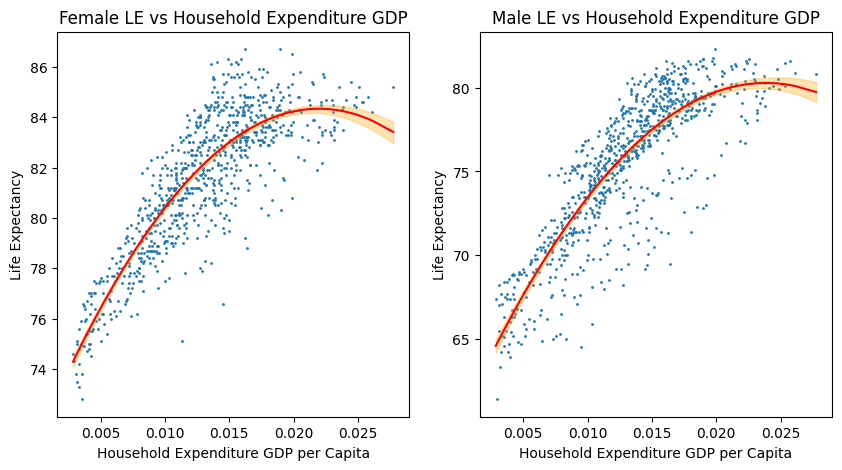

In [32]:
#Repeating previous plot now with the bootstrap error band shown
fig, axes = plt.subplots(1,2,sharex=True, figsize=(10,5))
axes[0].scatter(df['Household Expenditure GDP per Capital'],df['Female LE from 0'],s=1)
axes[0].set_title('Female LE vs Household Expenditure GDP')
axes[1].scatter(df['Household Expenditure GDP per Capital'],df['Male LE from 0'],s=1)
axes[1].set_title('Male LE vs Household Expenditure GDP')

#Add quadratic regression line

order = np.argsort(np.ravel(X))
y_f_est = np.polyval(np.flip(coef_f),np.ravel(X))
axes[0].plot(np.ravel(X)[order],y_f_est[order],color='red')

y_m_est = np.polyval(np.flip(coef_m),np.ravel(X))
axes[1].plot(np.ravel(X)[order],y_m_est[order],color='red')

axes[0].fill_between(x_uniform, bootstrap_band_f[0,:], bootstrap_band_f[1,:], color='orange', alpha=0.3)
axes[1].fill_between(x_uniform, bootstrap_band_m[0,:], bootstrap_band_m[1,:], color='orange', alpha=0.3)

axes[0].set_ylabel('Life Expectancy')
axes[1].set_ylabel('Life Expectancy')
axes[0].set_xlabel('Household Expenditure GDP per Capita')
axes[1].set_xlabel('Household Expenditure GDP per Capita')

These error bands demonstrate that this model is quite robust up until the high end of GDP, around 0.02, where the data is sparser. 

In [33]:
#Fit a robust linear and quadratic model using RANSAC algorithm to compare with the above results.

from sklearn.linear_model import RANSACRegressor

linear_ransac = RANSACRegressor(max_trials=1000)
quadratic_ransac = Pipeline([('poly', PolynomialFeatures(degree=2)),
                  ('ransac', RANSACRegressor(estimator=LinearRegression(fit_intercept=False),max_trials=1000))])

X = np.array(df.loc[mask]['Household Expenditure GDP per Capital']).reshape(-1,1)

ransac_l_f = linear_ransac.fit(X,df.loc[mask]['Female LE from 0'])
coef_l_f = np.array([ransac_l_f.estimator_.intercept_,ransac_l_f.estimator_.coef_[0]])

ransac_l_m = linear_ransac.fit(X,df.loc[mask]['Male LE from 0'])
coef_l_m = np.array([ransac_l_m.estimator_.intercept_,ransac_l_m.estimator_.coef_[0]])

ransac_q_f = quadratic_ransac.fit(X,df.loc[mask]['Female LE from 0'])
coef_q_f = ransac_q_f.named_steps['ransac'].estimator_.coef_

ransac_q_m = quadratic_ransac.fit(X,df.loc[mask]['Male LE from 0'])
coef_q_m = ransac_q_m.named_steps['ransac'].estimator_.coef_

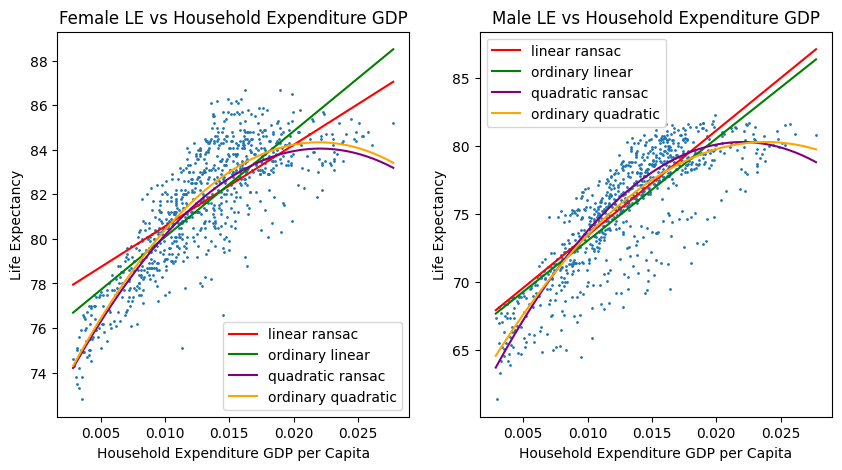

In [34]:
fig, axes = plt.subplots(1,2,sharex=True, figsize=(10,5))
axes[0].scatter(df['Household Expenditure GDP per Capital'],df['Female LE from 0'],s=1)
axes[0].set_title('Female LE vs Household Expenditure GDP')
axes[1].scatter(df['Household Expenditure GDP per Capital'],df['Male LE from 0'],s=1)
axes[1].set_title('Male LE vs Household Expenditure GDP')

#Add linear ransac and standard linear estimates
x_uniform = np.linspace(np.min(X),np.max(X))
y_l_f_est = np.polyval(np.flip(coef_l_f),x_uniform)
axes[0].plot(x_uniform,y_l_f_est,color='red',label='linear ransac')
y_l_f_old_est = np.polyval([lin_f.slope,lin_f.intercept],x_uniform)
axes[0].plot(x_uniform,y_l_f_old_est,color='green',label='ordinary linear')

y_l_m_est = np.polyval(np.flip(coef_l_m),x_uniform)
axes[1].plot(x_uniform,y_l_m_est,color='red',label='linear ransac')
y_l_m_old_est = np.polyval([lin_m.slope,lin_m.intercept],x_uniform)
axes[1].plot(x_uniform,y_l_m_old_est,color='green',label='ordinary linear')

#Add quadratic ransac and standard quadratic estimates
y_q_f_est = np.polyval(np.flip(coef_q_f),x_uniform)
axes[0].plot(x_uniform,y_q_f_est,color='purple',label='quadratic ransac')
y_q_f_old_est = np.polyval(np.flip(coef_f),x_uniform)
axes[0].plot(x_uniform,y_q_f_old_est,color='orange',label='ordinary quadratic')

y_q_m_est = np.polyval(np.flip(coef_q_m),x_uniform)
axes[1].plot(x_uniform,y_q_m_est,color='purple',label='quadratic ransac')
y_q_m_old_est = np.polyval(np.flip(coef_m),x_uniform)
axes[1].plot(x_uniform,y_q_m_old_est,color='orange',label='ordinary quadratic')


axes[0].set_ylabel('Life Expectancy')
axes[1].set_ylabel('Life Expectancy')
axes[0].set_xlabel('Household Expenditure GDP per Capita')
axes[1].set_xlabel('Household Expenditure GDP per Capita')
axes[0].legend()
axes[1].legend()

The use of an algorithm designed to be robust to outliers has had a small effect on both estimators. It is worth noting this is a random algorithm and so re-running this section will give different results each time. Sometimes there is more difference than others in the results, but I have not seen any instance of a large discrepancy. 

Can test the variability with another bootstrap.

In [35]:
#Repeat bootstrap estimates for both ransac estimators
bootstrap_indices = np.reshape(np.array(random.choices(np.array(range(len(df)))[np.array(mask)],k=len(mask)*n_sample)),(len(mask),n_sample))
bootstrap_coef_l_f = np.zeros((2,n_sample))
bootstrap_coef_l_m = np.zeros((2,n_sample))
bootstrap_coef_q_f = np.zeros((3,n_sample))
bootstrap_coef_q_m = np.zeros((3,n_sample))

for i in range(n_sample):
    ransac_l_f.fit(np.array(df.iloc[bootstrap_indices[:,i]]['Household Expenditure GDP per Capital']).reshape(-1,1),np.array(df.iloc[bootstrap_indices[:,i]]['Female LE from 0']))
    bootstrap_coef_l_f[:,i] = np.array([ransac_l_f.estimator_.intercept_,ransac_l_f.estimator_.coef_[0]])
    ransac_l_m.fit(np.array(df.iloc[bootstrap_indices[:,i]]['Household Expenditure GDP per Capital']).reshape(-1,1),np.array(df.iloc[bootstrap_indices[:,i]]['Male LE from 0']))
    bootstrap_coef_l_m[:,i] = np.array([ransac_l_m.estimator_.intercept_,ransac_l_m.estimator_.coef_[0]])
    
    ransac_q_f.fit(np.array(df.iloc[bootstrap_indices[:,i]]['Household Expenditure GDP per Capital']).reshape(-1,1),np.array(df.iloc[bootstrap_indices[:,i]]['Female LE from 0']))
    bootstrap_coef_q_f[:,i] = ransac_q_f.named_steps['ransac'].estimator_.coef_
    ransac_q_m.fit(np.array(df.iloc[bootstrap_indices[:,i]]['Household Expenditure GDP per Capital']).reshape(-1,1),np.array(df.iloc[bootstrap_indices[:,i]]['Male LE from 0']))
    bootstrap_coef_q_m[:,i] = ransac_q_m.named_steps['ransac'].estimator_.coef_

x_uniform = np.linspace(np.min(X),np.max(X))
bootstrap_vals_l_f = np.polyval(np.flip(bootstrap_coef_l_f,axis=0),np.outer(x_uniform,np.ones(n_sample)))
bootstrap_vals_l_m = np.polyval(np.flip(bootstrap_coef_l_m,axis=0),np.outer(x_uniform,np.ones(n_sample)))
bootstrap_vals_q_f = np.polyval(np.flip(bootstrap_coef_q_f,axis=0),np.outer(x_uniform,np.ones(n_sample)))
bootstrap_vals_q_m = np.polyval(np.flip(bootstrap_coef_q_m,axis=0),np.outer(x_uniform,np.ones(n_sample)))

bootstrap_band_l_f = np.quantile(bootstrap_vals_l_f,[0.025,0.975],axis=1)
bootstrap_band_l_m = np.quantile(bootstrap_vals_l_m,[0.025,0.975],axis=1)
bootstrap_band_q_f = np.quantile(bootstrap_vals_q_f,[0.025,0.975],axis=1)
bootstrap_band_q_m = np.quantile(bootstrap_vals_q_m,[0.025,0.975],axis=1)

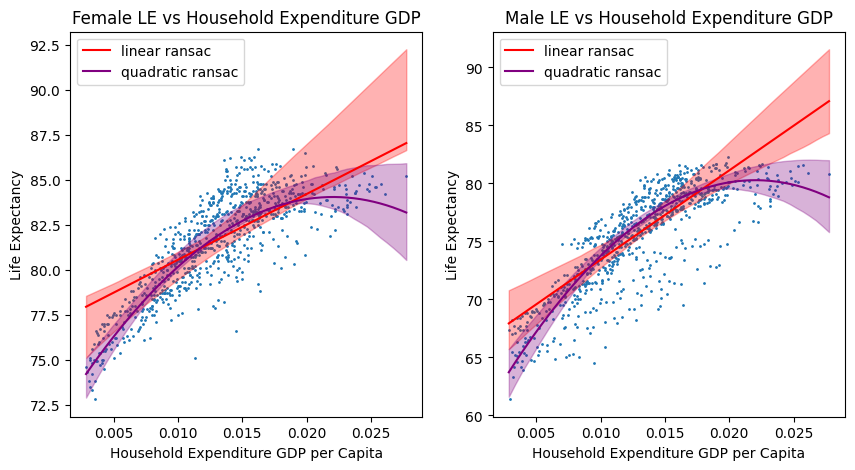

In [36]:
fig, axes = plt.subplots(1,2,sharex=True, figsize=(10,5))
axes[0].scatter(df['Household Expenditure GDP per Capital'],df['Female LE from 0'],s=1)
axes[0].set_title('Female LE vs Household Expenditure GDP')
axes[1].scatter(df['Household Expenditure GDP per Capital'],df['Male LE from 0'],s=1)
axes[1].set_title('Male LE vs Household Expenditure GDP')

x_uniform = np.linspace(np.min(X),np.max(X))
y_l_f_est = np.polyval(np.flip(coef_l_f),x_uniform)
axes[0].plot(x_uniform,y_l_f_est,color='red',label='linear ransac')

y_l_m_est = np.polyval(np.flip(coef_l_m),x_uniform)
axes[1].plot(x_uniform,y_l_m_est,color='red',label='linear ransac')

y_q_f_est = np.polyval(np.flip(coef_q_f),x_uniform)
axes[0].plot(x_uniform,y_q_f_est,color='purple',label='quadratic ransac')

y_q_m_est = np.polyval(np.flip(coef_q_m),x_uniform)
axes[1].plot(x_uniform,y_q_m_est,color='purple',label='quadratic ransac')

axes[0].fill_between(x_uniform, bootstrap_band_l_f[0,:], bootstrap_band_l_f[1,:], color='red', alpha=0.3)
axes[1].fill_between(x_uniform, bootstrap_band_l_m[0,:], bootstrap_band_l_m[1,:], color='red', alpha=0.3)
axes[0].fill_between(x_uniform, bootstrap_band_q_f[0,:], bootstrap_band_q_f[1,:], color='purple', alpha=0.3)
axes[1].fill_between(x_uniform, bootstrap_band_q_m[0,:], bootstrap_band_q_m[1,:], color='purple', alpha=0.3)


axes[0].set_ylabel('Life Expectancy')
axes[1].set_ylabel('Life Expectancy')
axes[0].set_xlabel('Household Expenditure GDP per Capita')
axes[1].set_xlabel('Household Expenditure GDP per Capita')
axes[0].legend()
axes[1].legend()

These plots show the much higher variability of this ransac algorithm compared with the usual least squares fit in this setting. Interestingly the quadratic fit appears more stable than the linear fit.

This drawback and the unclear improvement of this method on the final predicted curve suggests that the best model of these is the quadratic ordinary least squares.

A more formal analysis using performance on a test set could be done to verify this.